In [44]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from pylab import rcParams
rcParams['figure.figsize'] = 10, 8
rcParams['figure.dpi'] = 300

import torch
from torch import nn
from torch import distributions
from torch.nn.parameter import Parameter

from sklearn import datasets

In [45]:
class RealNVP(nn.Module):
    def __init__(self, dim, nets, nett, masks, prior):
        super().__init__()
        self.dim = int(dim)
        self.prior = prior

        if masks.ndim != 2 or masks.shape[1] != self.dim:
            raise ValueError(f"masks must have shape (num_coupling_layers, {self.dim})")

        self.mask = Parameter(masks, requires_grad=False)
        self.num_coupling_layers = masks.shape[0]
        self.t = nn.ModuleList([nett() for _ in range(self.num_coupling_layers)])
        self.s = nn.ModuleList([nets() for _ in range(self.num_coupling_layers)])

    def g(self, z):
        x = z
        for i in range(self.num_coupling_layers):
            mask = self.mask[i]
            x_ = x * mask
            s = self.s[i](x_) * (1 - mask)
            t = self.t[i](x_) * (1 - mask)
            x = x_ + (1 - mask) * (x * torch.exp(s) + t)
        return x

    def f(self, x):
        log_det_J = x.new_zeros(x.shape[0])
        z = x
        for i in reversed(range(self.num_coupling_layers)):
            mask = self.mask[i]
            z_ = z * mask
            s = self.s[i](z_) * (1 - mask)
            t = self.t[i](z_) * (1 - mask)
            z = z_ + (1 - mask) * (z - t) * torch.exp(-s)
            log_det_J -= s.sum(dim=1)
        return z, log_det_J

    def log_prob(self, x):
        z, log_det_J = self.f(x)
        return self.prior.log_prob(z) + log_det_J

    def sample(self, batch_size):
        z = self.prior.sample((batch_size,))
        return self.g(z)

## RealNVP 映射的数学模型

这一个单元格实现的是论文 *Real NVP* 中的可逆映射 $f: X \to Z$ 及其逆映射 $g=f^{-1}: Z \to X$。给定数据样本 $x$、潜变量 $z$ 和先验分布 $p_Z(z)$，模型使用变量代换公式定义数据分布：

$$
p_X(x) = p_Z\big(f(x)\big) \left| \det \left( \frac{\partial f(x)}{\partial x^T} \right) \right|
$$

因此对数似然可以写成：

$$
\log p_X(x) = \log p_Z\big(f(x)\big) + \log \left| \det \left( \frac{\partial f(x)}{\partial x^T} \right) \right|
$$

论文中最关键的构件是 affine coupling layer。若用二值 mask $m$ 将输入分成“保留部分”和“被变换部分”，则单层前向变换可以写成：

$$
y = m \odot x + (1-m) \odot \Big(x \odot \exp\big(s(m \odot x)\big) + t(m \odot x)\Big)
$$

这里 $s(\cdot)$ 是 scale 网络，$t(\cdot)$ 是 translation 网络，$\odot$ 表示按元素乘法。这个形式对应代码里的 `g`，也就是从潜空间生成数据空间：先保留被 mask 选中的坐标，再对其余坐标做仿射变换。

对应的逆变换就是代码里的 `f`：

$$
x = m \odot y + (1-m) \odot \Big(y - t(m \odot y)\Big) \odot \exp\big(-s(m \odot y)\big)
$$

因为这个 Jacobian 是三角矩阵，它的行列式只和被缩放的那部分有关，所以每层的 log-determinant 都可以高效计算。代码中的

$$
\texttt{log\_det\_J} \mathrel{-}= \sum_j s_j
$$

正是在累计逆映射 $f$ 的 Jacobian 对数行列式；最后 `log_prob(x)` 计算的是

$$
\log p_Z(z) + \log \left| \det \frac{\partial f(x)}{\partial x^T} \right|,
\quad z=f(x)
$$

这正对应论文中的精确似然估计。

In [46]:
def build_masks(dim, depth=3, dtype=torch.float32, device=None):
    if dim < 2:
        raise ValueError("dim must be at least 2")

    if dim % 2 == 0:
        masks = np.array([[1, 0] * (dim // 2), [0, 1] * (dim // 2)] * depth)
    else:
        masks = np.zeros((dim * depth, dim), dtype=np.float32)
        for i in range(dim * depth):
            masks[i, i % dim] = 1
    return torch.as_tensor(masks, dtype=dtype, device=device)


def build_prior(dim=2, prior_std=1.0, prior_mean=0.0, dtype=torch.float32, device=None):
    loc = torch.full((dim,), prior_mean, dtype=dtype, device=device)
    covariance_matrix = torch.eye(dim, dtype=dtype, device=device) * prior_std ** 2
    return distributions.MultivariateNormal(loc, covariance_matrix)


def build_model(device, dim=2, width=32, depth=3, scale=1.0, prior=None, dtype=torch.float32):
    def make_net(use_tanh=False):
        layers = [
            nn.Linear(dim, width),
            nn.LeakyReLU(),
            nn.Linear(width, width),
            nn.LeakyReLU(),
            nn.Linear(width, dim),
        ]
        if use_tanh:
            layers.append(nn.Tanh())
        net = nn.Sequential(*layers).to(dtype=dtype)
        for layer in net:
            if isinstance(layer, nn.Linear):
                layer.weight.data.mul_(scale)
                layer.bias.data.mul_(scale)
        return net

    nets = lambda: make_net(use_tanh=True)
    nett = lambda: make_net(use_tanh=False)
    masks = build_masks(dim, depth, dtype=dtype, device=device)

    if prior is None:
        prior = build_prior(dim=dim, dtype=dtype, device=device)

    return RealNVP(dim, nets, nett, masks, prior).to(device)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dim = 2
prior = build_prior(dim=dim, device=device)
flow = build_model(device, dim=dim, width=32, depth=5, prior=prior)

## 网络结构与模型构造

这个单元格把论文里的三个核心对象拆开构造：mask、先验分布 $p_Z$、以及每层 coupling layer 所需的 $s(\cdot)$ 和 $t(\cdot)$ 网络。

首先，`build_prior` 单独定义潜变量先验：

$$
z \sim \mathcal{N}(\mu, \sigma^2 I)
$$

这里代码默认使用各向同性高斯分布，并且把先验从网络结构中分离出来。这样做和论文里的设定一致，也更方便后续替换成别的 latent prior。

其次，`build_masks(dim, depth, ...)` 负责定义每一层 affine coupling 的分块方式。论文里写成把输入拆成两部分 $x_{1:d}$ 与 $x_{d+1:D}$，这里则用二值 mask $m$ 实现同样的操作：

- 当 `dim` 是偶数时，代码用交替的 `1010...` 和 `0101...` mask，让不同层轮流固定一半维度、更新另一半维度。
- 当 `dim` 是奇数时，代码改成循环 one-hot mask，让每一层固定一个坐标、更新其余坐标，从而把同样的 coupling 思想推广到任意维度。

最后，`build_model` 构造论文中的 $s(\cdot)$ 和 $t(\cdot)$。在当前 notebook 里，这两个函数都由 MLP 近似：

$$
s,t : \mathbb{R}^{\text{dim}} \to \mathbb{R}^{\text{dim}}
$$

具体结构是：

$$
\text{Linear(dim, width)} \to \text{LeakyReLU} \to \text{Linear(width, width)} \to \text{LeakyReLU} \to \text{Linear(width, dim)}
$$

其中：

- `nett()` 对应平移网络 $t(\cdot)$，输出不加约束。
- `nets()` 对应缩放网络 $s(\cdot)$，最后接一个 `Tanh()`，用于把缩放输出限制在较稳定的范围内，避免 `\exp(s)` 过大导致训练不稳定。
- `width` 控制每个 MLP 的隐藏层宽度。
- `depth` 控制 coupling layer 的层数，也就是 mask 的重复次数，而不是单个 MLP 的隐藏层深度。
- `scale` 通过缩放线性层初始参数，让初始变换更接近恒等映射，这通常有助于 flow 模型在训练初期更稳定。

综合起来，这个单元格实现的是：先选定先验 $p_Z$，再构造一组 mask 和一组 $s/t$ 子网络，最后把它们打包进 `RealNVP(dim, nets, nett, masks, prior)`，从而得到一个可以同时做密度估计与采样的可逆模型。

In [47]:
optimizer = torch.optim.Adam([p for p in flow.parameters() if p.requires_grad], lr=1e-4)
model_dtype = next(flow.parameters()).dtype
for t in range(5001):
    noisy_moons = datasets.make_moons(n_samples=100, noise=.05)[0].astype(np.float32)
    batch = torch.from_numpy(noisy_moons).to(device=device, dtype=model_dtype)
    loss = -flow.log_prob(batch).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 500 == 0:
        print('iter %s:' % t, 'loss = %.3f' % loss.item())

iter 0: loss = 2.879
iter 500: loss = 1.196
iter 1000: loss = 0.948
iter 1500: loss = 0.740
iter 2000: loss = 0.695
iter 2500: loss = 0.721
iter 3000: loss = 0.467
iter 3500: loss = 0.492
iter 4000: loss = 0.403
iter 4500: loss = 0.313
iter 5000: loss = 0.352


## 最大似然Loss

训练单元里核心语句是：

$$
\texttt{loss} = -\frac{1}{B}\sum_{i=1}^{B} \log p_X(x_i)
$$

其中 $\{x_i\}_{i=1}^B$ 是一个 mini-batch（这里由 `make_moons` 采样得到），$p_X$ 是 RealNVP 在数据空间上的密度。这个目标就是**负对数似然（Negative Log-Likelihood, NLL）**，等价于最大化对数似然（MLE）。

在 RealNVP 中，密度通过可逆映射 $z=f(x)$ 和变量代换公式计算：

$$
\log p_X(x)
= \log p_Z\big(f(x)\big)
+ \log\left|\det\left(\frac{\partial f(x)}{\partial x^T}\right)\right|
$$

因此第 $i$ 个样本的对数似然可写为：

$$
\log p_X(x_i)
= \log p_Z(z_i) + \log|\det J_f(x_i)|,
\quad z_i=f(x_i)
$$

对应到代码中：

- `flow.f(batch)` 计算 $z$ 和逐样本的 Jacobian 对数行列式累计项；
- `self.prior.log_prob(z)` 给出 $\log p_Z(z)$；
- `flow.log_prob(batch)` 返回逐样本 $\log p_X(x)$；
- 最后 `.mean()` 做 batch 平均，前面的负号把“最大化对数似然”转成优化器常用的“最小化损失”。

所以该案例的训练目标可总结为：

$$
\min_{\theta}\; \mathcal{L}(\theta)
= -\mathbb{E}_{x\sim \hat p_{\text{data}}}\big[\log p_X(x;\theta)\big]
\approx -\frac{1}{B}\sum_{i=1}^{B}\log p_X(x_i;\theta)
$$

这正是 normalizing flow 的标准最大似然训练目标。

Text(0.5, 1.0, '$X = g(z)$')

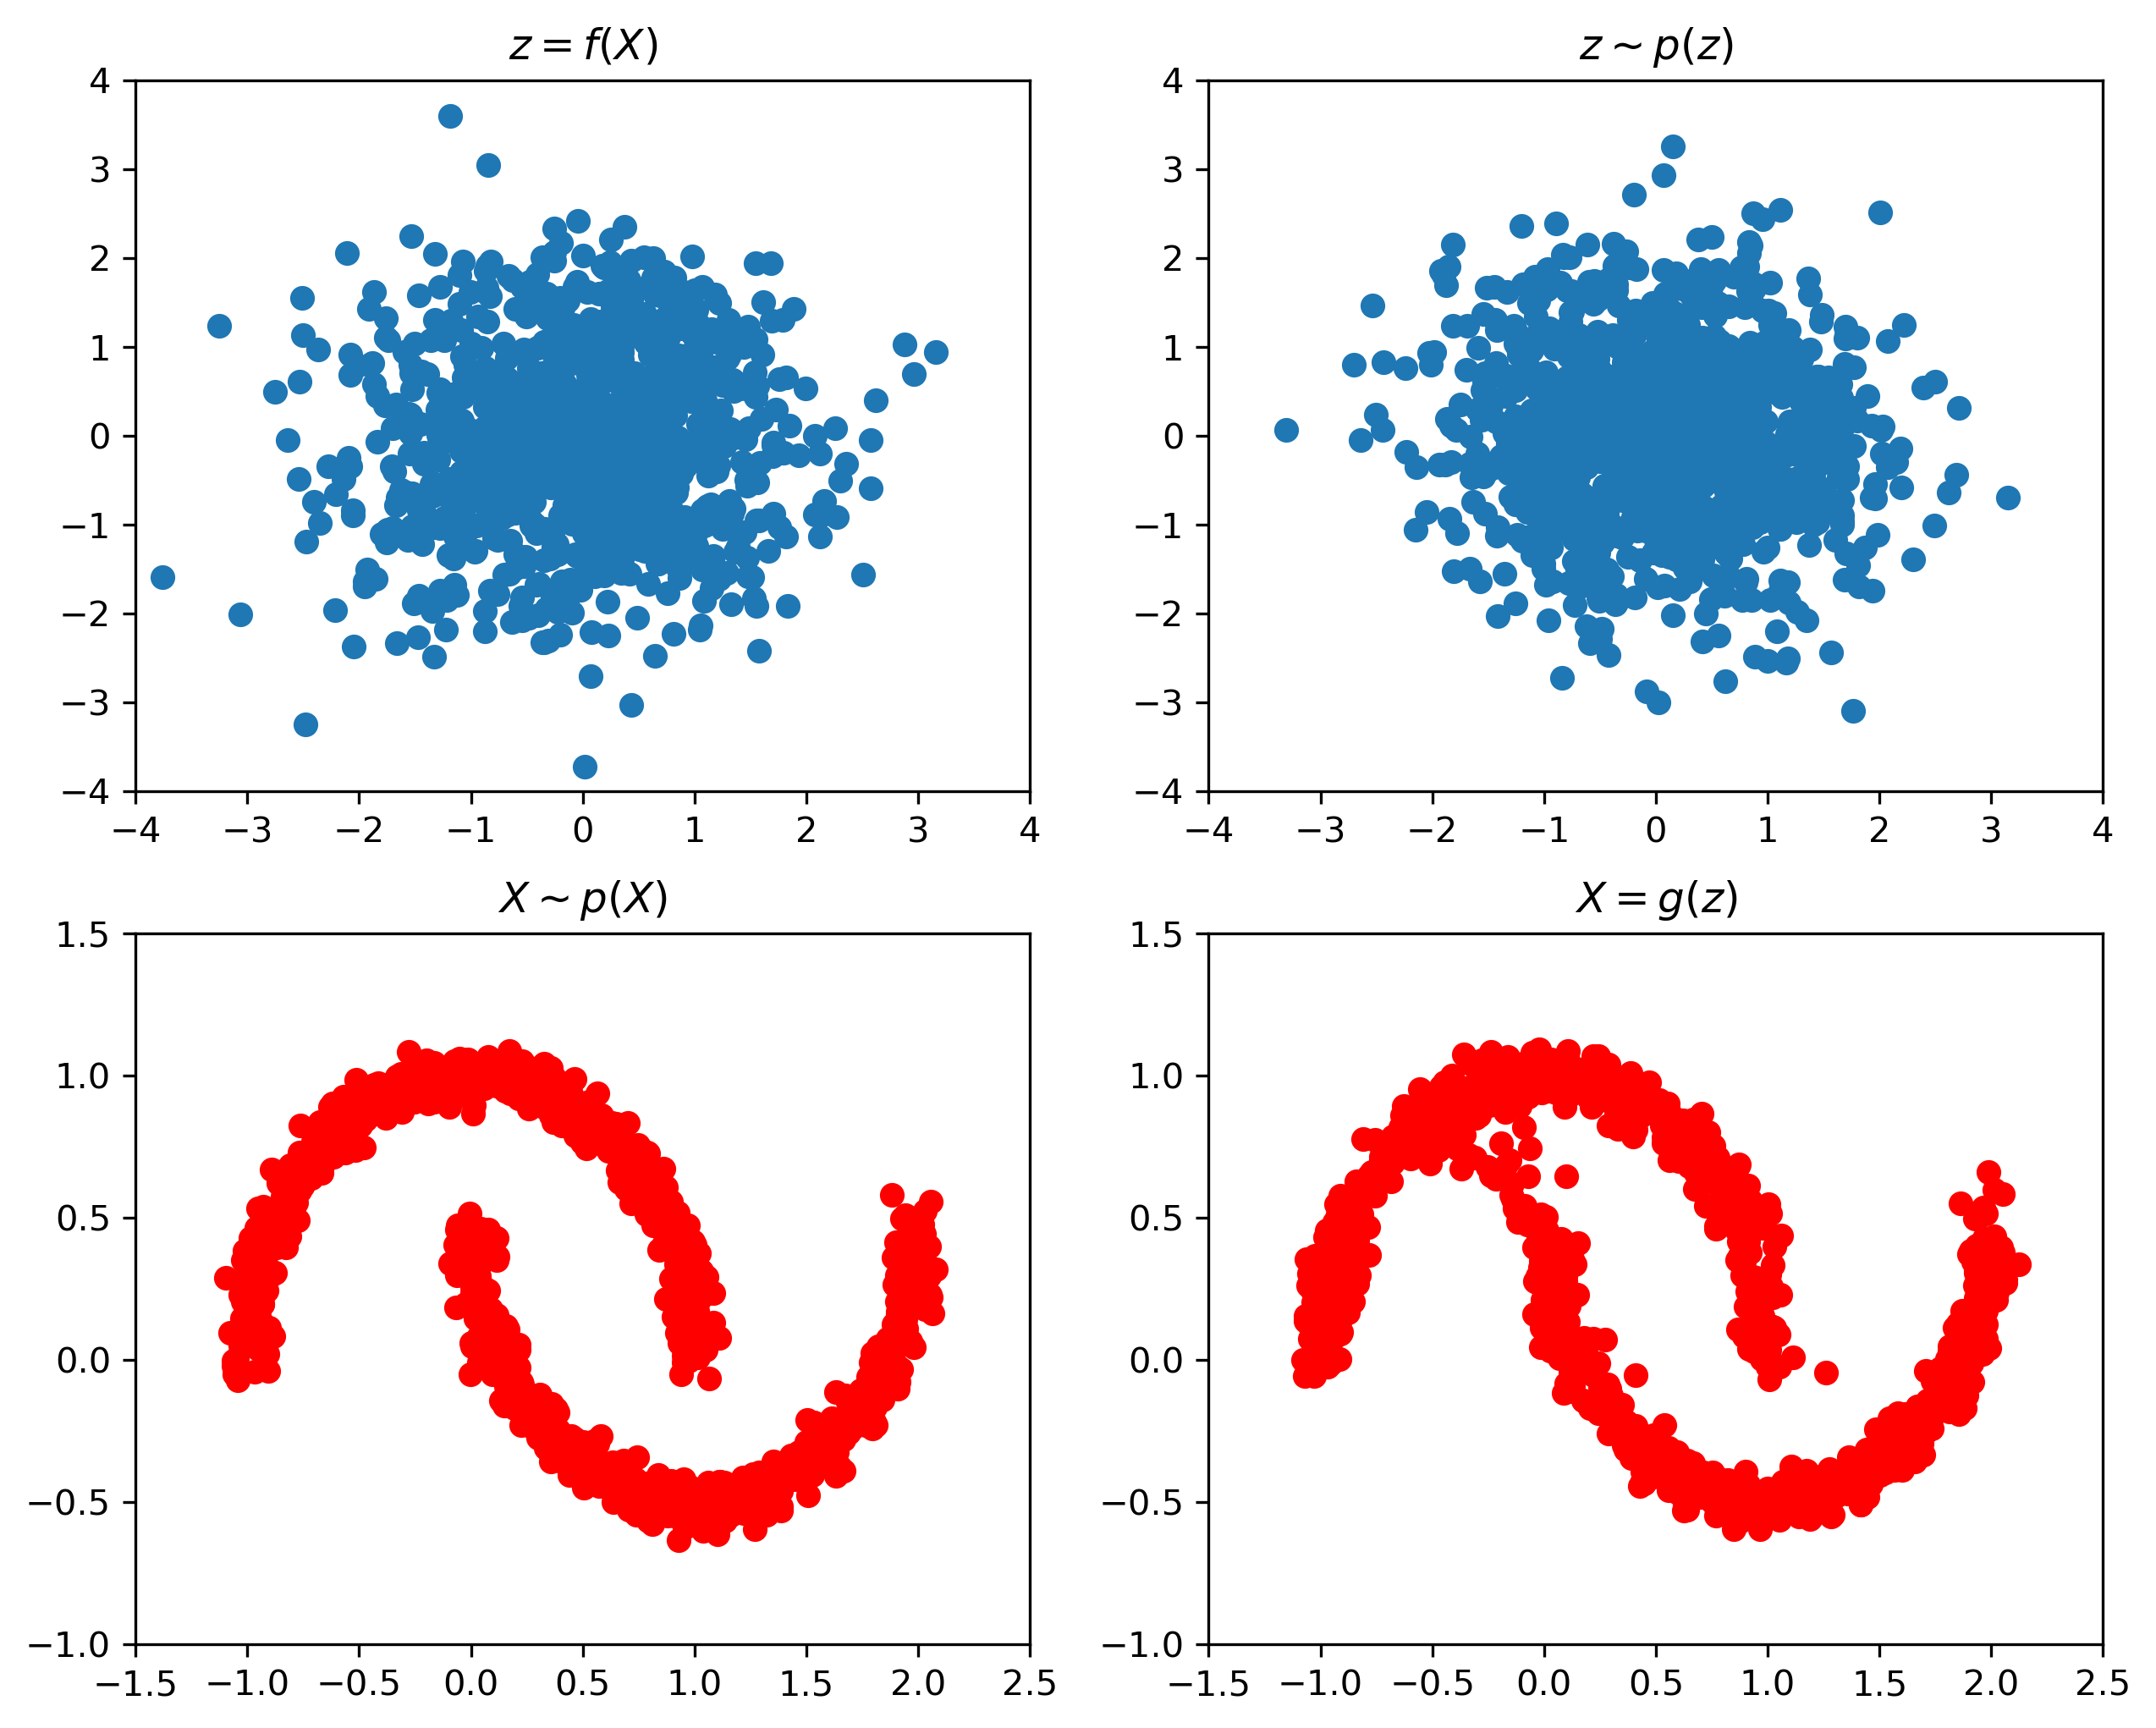

In [48]:
noisy_moons = datasets.make_moons(n_samples=1000, noise=.05)[0].astype(np.float32)
batch = torch.from_numpy(noisy_moons).to(device=device, dtype=model_dtype)
z = flow.f(batch)[0].detach().cpu().numpy()
plt.subplot(221)
plt.scatter(z[:, 0], z[:, 1])
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title(r'$z = f(X)$')

z = prior.sample((1000,)).detach().cpu().numpy()
plt.subplot(222)
plt.scatter(z[:, 0], z[:, 1])
plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.title(r'$z \sim p(z)$')

plt.subplot(223)
x = datasets.make_moons(n_samples=1000, noise=.05)[0].astype(np.float32)
plt.scatter(x[:, 0], x[:, 1], c='r')
plt.xlim(-1.5, 2.5)
plt.ylim(-1.0, 1.5)
plt.title(r'$X \sim p(X)$')

plt.subplot(224)
x = flow.sample(1000).detach().cpu().numpy()
plt.scatter(x[:, 0], x[:, 1], c='r')
plt.xlim(-1.5, 2.5)
plt.ylim(-1.0, 1.5)
plt.title(r'$X = g(z)$')